In [ ]:
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from scipy.stats import ks_2samp
from datetime import datetime, time
import os

In [2]:

chemin23="fichiersexceluniformises/2023"
df_votre = pd.read_excel(os.path.join(chemin23, '11.xlsx'))
df=df_votre
# Afficher les 20 premières valeurs brutes de la colonne Start
print(df['Start'].dropna().unique()[:20])


['05/11/2023 23:55' '05/11/2023 23:54' '05/11/2023 23:45'
 '05/11/2023 23:44' '05/11/2023 23:42' '05/11/2023 23:41'
 '05/11/2023 23:38' '05/11/2023 23:34' '05/11/2023 23:33'
 '05/11/2023 23:32' '05/11/2023 23:31' '05/11/2023 23:27'
 '05/11/2023 23:26' '05/11/2023 23:23' '05/11/2023 23:22'
 '05/11/2023 23:21' '05/11/2023 23:19' '05/11/2023 23:17'
 '05/11/2023 23:14' '05/11/2023 23:13']


In [3]:
df.shape

(168780, 5)

In [4]:
import pandas as pd
# Conversion robuste de la colonne Start avec dayfirst=True
df['Start'] = pd.to_datetime(df['Start'].str.strip(), dayfirst=True, errors='coerce')
# Formater la colonne Start en string avec format précis
df['Start'] = df['Start'].dt.strftime('%Y-%m-%d')
print(df['Start'].head())

0    2023-11-05
1    2023-11-05
2    2023-11-05
3    2023-11-05
4    2023-11-05
Name: Start, dtype: object


In [5]:
df.shape

(168780, 5)

In [6]:
from datetime import datetime

def parse_date_time(date_str):
    """
    Parse une date-heure en string au format dd/mm/yyyy HH:MM ou dd/mm/yyyy HH:MM:SS,
    retourne la date au format yyyy-mm-dd et l'heure au format HH:MM:SS.
    """
    # Tester si la chaîne contient des secondes (en cherchant le nombre de ':')
    parts = date_str.strip().split(' ')
    if len(parts) != 2:
        # Format inattendu, renvoyer None
        return None, None
    
    date_part, time_part = parts
    
    # Ajouter les secondes si manquent
    if time_part.count(':') == 1:
        time_part += ':00'
    
    # Construire la chaîne complète au format attendu
    full_str = date_part + ' ' + time_part
    
    # Parser avec datetime en précisant le format
    try:
        dt = datetime.strptime(full_str, '%d/%m/%Y %H:%M:%S')
    except ValueError:
        # Si erreur de parsing, renvoyer None
        return None, None
    
    # Formater date et heure séparément
    date_formatted = dt.strftime('%Y-%m-%d')
    time_formatted = dt.strftime('%H:%M:%S')
    
    return date_formatted, time_formatted


In [7]:
dates = [
    '26/11/2023 00:44', 
    '26/11/2023 00:43', 
    '26/11/2023 00:41',
    '27/11/2023 13:22:15'  # avec secondes
]

for d in dates:
    date_only, time_only = parse_date_time(d)
    print(f"Original: {d} --> Date: {date_only} / Time: {time_only}")


Original: 26/11/2023 00:44 --> Date: 2023-11-26 / Time: 00:44:00
Original: 26/11/2023 00:43 --> Date: 2023-11-26 / Time: 00:43:00
Original: 26/11/2023 00:41 --> Date: 2023-11-26 / Time: 00:41:00
Original: 27/11/2023 13:22:15 --> Date: 2023-11-27 / Time: 13:22:15


In [9]:
import os
import pandas as pd
from datetime import datetime

# Fonction de parsing perso
def parse_date_time(date_str):
    if pd.isna(date_str):
        return None, None
    parts = str(date_str).strip().split(' ')
    if len(parts) != 2:
        return None, None
    date_part, time_part = parts
    if time_part.count(':') == 1:
        time_part += ':00'
    full_str = date_part + ' ' + time_part
    try:
        dt = datetime.strptime(full_str, '%d/%m/%Y %H:%M:%S')
    except ValueError:
        return None, None
    date_formatted = dt.strftime('%Y-%m-%d')
    time_formatted = dt.strftime('%H:%M:%S')
    return date_formatted, time_formatted

# Chemin et fichier
chemin23 = "fichiersexceluniformises/2023"
file_name = '11.xlsx'

# Lire le fichier Excel
df_votre = pd.read_excel(os.path.join(chemin23, file_name))
df = df_votre.copy()

# Appliquer la fonction à la colonne 'Start' et créer deux colonnes
df[['Start', 'Time']] = df['Start'].apply(lambda x: pd.Series(parse_date_time(x)))

# Sauvegarder dans un nouveau fichier Excel
output_path = os.path.join(chemin23, 'cleaned_11_2.xlsx')
df.to_excel(output_path, index=False)

print(f"Fichier nettoyé sauvegardé sous : {output_path}")


Fichier nettoyé sauvegardé sous : fichiersexceluniformises/2023\cleaned_11_2.xlsx


In [11]:
import os
import pandas as pd

# Charger le fichier
chemin23 = "fichiersexceluniformises/2023"
file_name = 'cleaned_11_2.xlsx'
input_path = os.path.join(chemin23, file_name)
df = pd.read_excel(input_path)

# Convertir tous les CPID en chaînes, en supprimant les espaces et remplaçant NaN par une chaîne vide
df['CPID'] = df['CPID'].astype(str).str.strip().fillna("")

# Sauvegarder le fichier nettoyé
output_file = 'cleaned_cpid_11_2.xlsx'
output_path = os.path.join(chemin23, output_file)
df.to_excel(output_path, index=False)
print(f" Fichier enregistré sous : {output_path}")

 Fichier enregistré sous : fichiersexceluniformises/2023\cleaned_cpid_11_2.xlsx


In [13]:
chemin23 = "fichiersexceluniformises/2023"
file_name = 'cleaned_cpid_11_2.xlsx'
input_path = os.path.join(chemin23, file_name)
df = pd.read_excel(input_path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168780 entries, 0 to 168779
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Amount         168780 non-null  float64
 1   CPID           168780 non-null  object 
 2   Consumed(kWh)  168780 non-null  float64
 3   Duration       168778 non-null  object 
 4   Start          168780 non-null  object 
 5   Time           168780 non-null  object 
dtypes: float64(2), object(4)
memory usage: 7.7+ MB


In [14]:

# Chargement des correspondances CPID et autorités locales
ChargerID = pd.read_excel('CPID_and_local_authority.xlsx')
# Corrections manuelles
ChargerID.loc[ChargerID['CPID'] == 61625, 'local_authority'] = 'Renfrewshire'
ChargerID.loc[ChargerID['CPID'] == 'CMU2211', 'local_authority'] = 'North Lanarkshire'
# Charger le fichier
ChargerID = pd.read_excel('CPID_and_local_authority.xlsx')
# Transformer la colonne CPID en string propre (en supprimant les espaces si besoin)
ChargerID['CPID'] = ChargerID['CPID'].astype(str).str.strip().fillna("")
# Optionnel : afficher les premiers CPID pour vérification
print(ChargerID['CPID'].head())
#merging Charger ID with df to attach LA data based on CPID
merged_df = pd.merge(df, ChargerID, on='CPID', how='left')



0       61561
1       61562
2       61296
3       60381
4    APT60399
Name: CPID, dtype: object


In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168780 entries, 0 to 168779
Data columns (total 7 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Amount           168780 non-null  float64
 1   CPID             168780 non-null  object 
 2   Consumed(kWh)    168780 non-null  float64
 3   Duration         168778 non-null  object 
 4   Start            168780 non-null  object 
 5   Time             168780 non-null  object 
 6   local_authority  168609 non-null  object 
dtypes: float64(2), object(5)
memory usage: 9.0+ MB


In [16]:
# === 3. Charger et nettoyer CPID_and_charger_speed.xlsx ===
charger_speeds = pd.read_excel('CPID_and_charger_speed.xlsx')
charger_speeds['CPID'] = charger_speeds['CPID'].astype(str).str.strip().fillna("")

In [17]:
#removing data where energy consumed = 0kWh
merged_df = merged_df[merged_df['Consumed(kWh)']>0]
#removing sessions where duration is 00:00:00
merged_df = merged_df[merged_df['Duration'] != pd.to_datetime('00:00:00').time()]
#removing nulls from merged_df
merged_df = merged_df.dropna()
merged_df.shape

(158686, 7)

In [ ]:
#bringing in 8-fold rural urban classification
UR8class = pd.read_excel("CPID_and_UR_Classification.xlsx")
UR8class['CPID'] = UR8class['CPID'].astype(str).str.strip().fillna("")

In [ ]:
#correcting nulls from GIS
UR8class.loc[UR8class['CPID']==62931, 'UR8Class'] = 5
UR8class.loc[UR8class['CPID']==62932, 'UR8Class'] = 5
#merging 8-fold with session data based on CPID
merged_df = pd.merge(merged_df, UR8class, on='CPID', how='left')
#removing nulls
merged_df = merged_df.dropna()

In [121]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156957 entries, 0 to 158685
Data columns (total 8 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Amount           156957 non-null  float64
 1   CPID             156957 non-null  object 
 2   Consumed(kWh)    156957 non-null  float64
 3   Duration         156957 non-null  object 
 4   Start            156957 non-null  object 
 5   Time             156957 non-null  object 
 6   local_authority  156957 non-null  object 
 7   UR8Class         156957 non-null  float64
dtypes: float64(3), object(5)
memory usage: 10.8+ MB


In [ ]:

SIMD = pd.read_excel("CPID_and_SIMD.xlsx")
SIMD['CPID'] = SIMD['CPID'].astype(str).str.strip().fillna("")
#correcting nulls from GIS
SIMD.loc[SIMD['CPID']==62931, 'Rankv2'] = 558
SIMD.loc[SIMD['CPID']==62932, 'Rankv2'] = 558
SIMD.loc[SIMD['CPID']==50540, 'Rankv2'] = 3763
SIMD.loc[SIMD['CPID']==50796, 'Rankv2'] = 3763
SIMD.loc[SIMD['CPID']==50797, 'Rankv2'] = 3763
SIMD.loc[SIMD['CPID']==51500, 'Rankv2'] = 3763
SIMD.loc[SIMD['CPID']==51961, 'Rankv2'] = 1400
SIMD.loc[SIMD['CPID']==52112, 'Rankv2'] = 1400
SIMD.loc[SIMD['CPID']=='1712508020/B94060093', 'Rankv2'] = 1400
SIMD.loc[SIMD['CPID']=='T54-1T1-1319-117', 'Rankv2'] = 1400
#merging SIMD rank data with the rest
merged_df = pd.merge(merged_df, SIMD, on='CPID', how='left')
#removing any nulls in updated main dataset
merged_df = merged_df.dropna()

In [123]:
merged_df.shape

(156957, 9)

In [ ]:
GAcc = pd.read_excel("CPID_and_GA.xlsx")
#correcting nulls from GIS
GAcc.loc[GAcc['CPID']==62931, 'GAccRank'] = 6516
GAcc.loc[GAcc['CPID']==62932, 'GAccRank'] = 6516
GAcc.loc[GAcc['CPID']==50540, 'GAccRank'] = 5336
GAcc.loc[GAcc['CPID']==50796, 'GAccRank'] = 5336
GAcc.loc[GAcc['CPID']==50797, 'GAccRank'] = 5336
GAcc.loc[GAcc['CPID']==51500, 'GAccRank'] = 5336
GAcc.loc[GAcc['CPID']==51961, 'GAccRank'] = 4652
GAcc.loc[GAcc['CPID']==52112, 'GAccRank'] = 4652
GAcc.loc[GAcc['CPID']=='1712508020/B94060093', 'GAccRank'] = 4652
GAcc.loc[GAcc['CPID']=='T54-1T1-1319-117', 'GAccRank'] = 4652
GAcc['CPID'] = GAcc['CPID'].astype(str).str.strip().fillna("")
#merging SIMD GeoAccess rank data with the rest
merged_df = pd.merge(merged_df, GAcc, on='CPID', how='left')
#removing any nulls in updated main dataset
merged_df = merged_df.dropna()

In [125]:
merged_df.shape

(156957, 10)

In [126]:
#bringing in and attaching postcodes
postcodes = pd.read_excel('CPID_and_postcode.xlsx')
postcodes['CPID'] = postcodes['CPID'].astype(str).str.strip().fillna("")
merged_df = pd.merge(merged_df, postcodes, on='CPID', how='left')
merged_df = merged_df.dropna()

In [127]:
merged_df.shape

(156957, 11)

In [128]:
#removing any duplicated sessions
data = merged_df.drop_duplicates()
##removing sessions where >118kWh was drawn
##These sessions are incompatible with the usable battery capacity of the EV
##with the larges usable battery capacity according to EV Database
##https://ev-database.org/uk/cheatsheet/useable-battery-capacity-electric-car
data = data[data['Consumed(kWh)']<=118]
##removing sessions where amount paid is >£1471 based on cost of 24h duration charge
##for 118kWh battery on an East Renfrewshire Council rapid charger (largest tariff
##plus overstay fee on CPS network at time of writing)
data = data[data['Amount']<=1471]

In [129]:
data.info()
data.shape

<class 'pandas.core.frame.DataFrame'>
Index: 156956 entries, 0 to 156956
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Amount           156956 non-null  float64
 1   CPID             156956 non-null  object 
 2   Consumed(kWh)    156956 non-null  float64
 3   Duration         156956 non-null  object 
 4   Start            156956 non-null  object 
 5   Time             156956 non-null  object 
 6   local_authority  156956 non-null  object 
 7   UR8Class         156956 non-null  float64
 8   Rankv2           156956 non-null  int64  
 9   GAccRank         156956 non-null  int64  
 10  Postcode         156956 non-null  object 
dtypes: float64(3), int64(2), object(6)
memory usage: 14.4+ MB


(156956, 11)

In [ ]:
#adding charger speed data
data = pd.merge(data, ChargerSpeeds, on='CPID', how='left')
#assigning missing data
data.loc[data['CPID']==60942, 'Connector_Type'] = 'AC'
data.loc[data['CPID']==62009, 'Connector_Type'] = 'AC'
data.loc[data['CPID']==60979, 'Connector_Type'] = 'AC'
data.loc[data['CPID']=='APT51333', 'Connector_Type'] = 'Rapid'
#removing anomalous data
data2 = data.copy()
dates_to_remove = ['2022-10-30', '2023-10-01', '2024-02-04', '2023-03-06', '2023-03-07', '2023-03-08', '2023-03-09', '2023-03-10', '2023-03-11', '2023-03-12', '2023-06-05', '2023-06-06', '2023-06-07', '2023-06-08', '2023-06-09', '2023-06-10', '2023-06-11']
data2 = data2[~data2['Start'].isin(dates_to_remove)]
#converting Start to date format
data2['Start'] = pd.to_datetime(data2['Start']).dt.date
#assigning quintiles according to ScotGov values
def assign_quintile(x):
    if x <= 1395:
        return 1
    elif x <= 2790:
        return 2
    elif x <= 4185:
        return 3
    elif x <= 5580:
        return 4
    else:
        return 5

data2['Rankv2_quintile'] = data2['Rankv2'].apply(assign_quintile)
data2['GAccRank_quintile'] = data2['GAccRank'].apply(assign_quintile)

######finding average GAcc rank/quintile of chargers in each LA
avg_acc = data2[['CPID', 'local_authority', 'GAccRank_quintile']].drop_duplicates()
avg_acc = avg_acc.groupby('local_authority')['GAccRank_quintile'].mean().reset_index()
avg_acc = avg_acc.rename(columns={'GAccRank_quintile':'avg_GAcc_quin'})

avg_acc2 = data2[['CPID', 'local_authority', 'GAccRank']].drop_duplicates()
avg_acc2 = avg_acc2.groupby('local_authority')['GAccRank'].mean().reset_index()
avg_acc2 = avg_acc2.rename(columns={'GAccRank':'avg_GAcc'})

###################################PLOTTING####################################

#####plotting number of daily sessions and number of chargers observed

#grouping by start date and finding number of unique CPIDs as they appear on daily basis
unique_CPIDs_per_day = data2.groupby('Start')['CPID'].apply(lambda x: x.unique()).reset_index()

#counting number of unique CPIDs as they appear in the dataset
cumulative_unique_ids_day = set()
cumulative_counts = []

for _, row in unique_CPIDs_per_day.iterrows():
    cumulative_unique_ids_day.update(row['CPID'])
    cumulative_counts.append({
        'Start': row['Start'],
        'Cumulative_Unique_CPID_Count_Day': len(cumulative_unique_ids_day)
    })

#converting cumulative counts to a dataframe
cumulative_counts_CPID = pd.DataFrame(cumulative_counts)

#finding the total number of sessions per day
sessions_per_day = data2.groupby('Start').size().reset_index(name='session_count')

#merging to give a dataframe with the total number of sessions per day and the cumulative number of chargers observed
sessions_chargers = pd.merge(sessions_per_day, cumulative_counts_CPID, how='left', left_on='Start', right_on='Start')

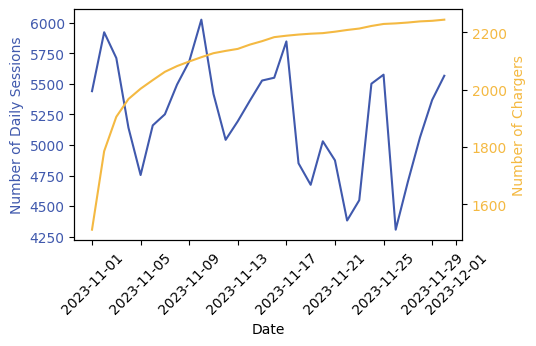

In [ ]:
#plotting
fig, ax1 = plt.subplots(figsize=(5, 3))  # largeur=5 pouces, hauteur=3 pouces
color = '#4059AD'
ax1.set_xlabel('Date') 
ax1.set_ylabel('Number of Daily Sessions', color = color) 
plt.xticks(rotation=45)
ax1.plot(sessions_chargers.Start, sessions_chargers.session_count, color = color) 
ax1.tick_params(axis ='y', labelcolor = color) 

ax2 = ax1.twinx() 

color = '#F4B942'
ax2.set_ylabel('Number of Chargers', color = color) 
ax2.plot(sessions_chargers.Start, sessions_chargers.Cumulative_Unique_CPID_Count_Day, color = color) 
ax2.tick_params(axis ='y', labelcolor = color)

plt.show()